In [1]:
import pandas as pd

nav = pd.read_csv("data/processed/02_nav_history_cleaned.csv")

print(nav.head())

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("reports/charts", exist_ok=True)

print("Setup done")

Setup done


In [3]:
nav = pd.read_csv("data/processed/02_nav_history_cleaned.csv")
fund_master = pd.read_csv("data/processed/01_fund_master_cleaned.csv")
transactions = pd.read_csv("data/processed/08_investor_transactions_cleaned.csv")
holdings = pd.read_csv("data/processed/09_portfolio_holdings_cleaned.csv")
performance = pd.read_csv("data/processed/07_scheme_performance_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

print("Data loaded")

Data loaded


In [4]:
nav = nav.sort_values(["amfi_code", "date"])
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

var_rows = []

for code, group in nav.groupby("amfi_code"):
    returns = group["daily_return"].dropna()

    var_95 = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean()

    var_rows.append({
        "amfi_code": code,
        "VaR_95": var_95,
        "CVaR_95": cvar_95
    })

var_cvar = pd.DataFrame(var_rows)

var_cvar = var_cvar.merge(
    fund_master[["amfi_code", "scheme_name", "fund_house", "risk_category"]],
    on="amfi_code",
    how="left"
)

var_cvar.to_csv("data/processed/var_cvar_report.csv", index=False)

var_cvar.head()

,amfi_code,VaR_95,CVaR_95,scheme_name,fund_house,risk_category
0,100016,-0.014364,-0.018060,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Moderate
1,100025,-0.003793,-0.004994,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Low
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,High
3,101206,-0.013282,-0.017439,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Moderate
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Very High


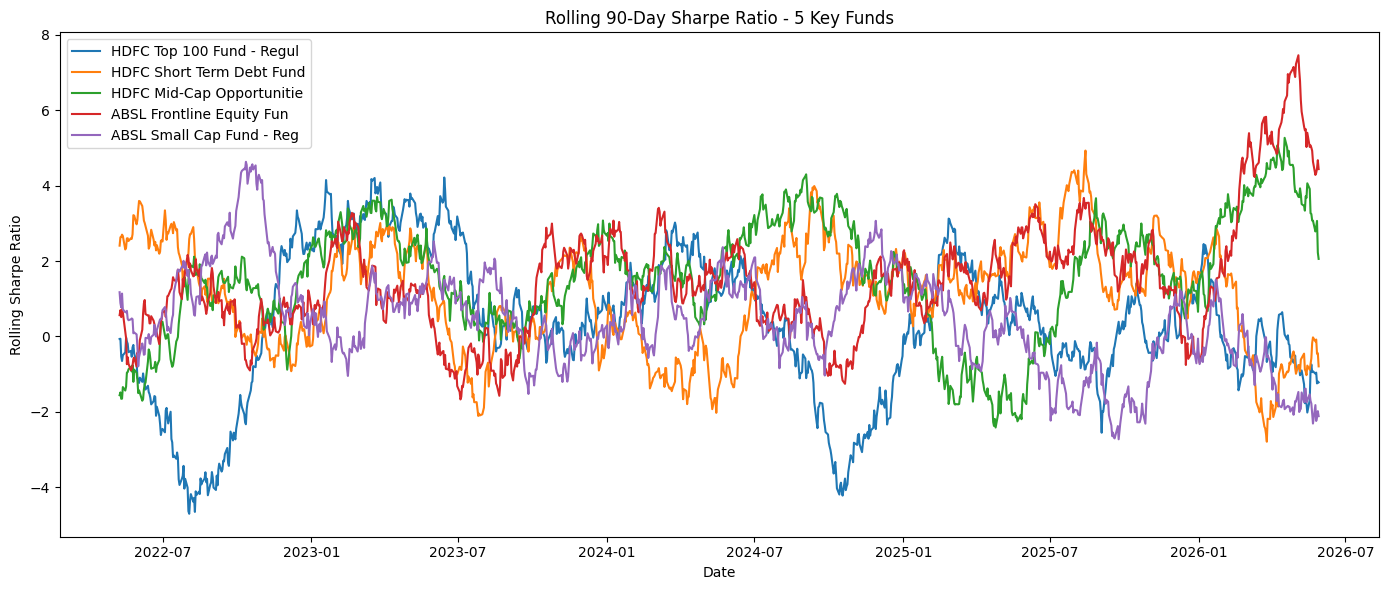

In [5]:
selected_funds = nav["amfi_code"].unique()[:5]

plt.figure(figsize=(14, 6))

for code in selected_funds:
    temp = nav[nav["amfi_code"] == code].copy()
    temp = temp.sort_values("date")

    temp["rolling_sharpe_90"] = (
        temp["daily_return"].rolling(90).mean()
        /
        temp["daily_return"].rolling(90).std()
    ) * np.sqrt(252)

    scheme_name = fund_master.loc[
        fund_master["amfi_code"] == code,
        "scheme_name"
    ].values[0]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe_90"],
        label=scheme_name[:25]
    )

plt.title("Rolling 90-Day Sharpe Ratio - 5 Key Funds")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend()
plt.tight_layout()

plt.savefig("reports/charts/rolling_sharpe_chart.png", dpi=300)
plt.show()

In [6]:
# Investor Cohort Analysis

transactions["first_transaction_year"] = (
    transactions.groupby("investor_id")["transaction_date"]
    .transform("min")
    .dt.year
)

cohort_summary = (
    transactions.groupby("first_transaction_year")
    .agg(
        avg_transaction_amount=("amount_inr", "mean"),
        total_invested=("amount_inr", "sum"),
        total_investors=("investor_id", "nunique")
    )
    .reset_index()
)

cohort_summary


,first_transaction_year,avg_transaction_amount,total_invested,total_investors
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [7]:
cohort_fund_pref = (
    transactions.groupby(["first_transaction_year", "amfi_code"])
    .size()
    .reset_index(name="transaction_count")
)

cohort_fund_pref = cohort_fund_pref.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

top_fund_per_cohort = (
    cohort_fund_pref.sort_values(
        ["first_transaction_year", "transaction_count"],
        ascending=[True, False]
    )
    .groupby("first_transaction_year")
    .head(1)
)

top_fund_per_cohort

,first_transaction_year,amfi_code,transaction_count,scheme_name
35,2024,148568,874,Mirae Asset Emerging Bluechip Fund - Regular -...
62,2025,119599,12,SBI Small Cap Fund - Direct Plan - Growth


In [8]:
sip_tx = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

sip_tx = sip_tx.sort_values(
    ["investor_id", "transaction_date"]
)

sip_tx["gap_days"] = (
    sip_tx.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip_summary = (
    sip_tx.groupby("investor_id")
    .agg(
        sip_count=("transaction_date", "count"),
        avg_gap_days=("gap_days", "mean")
    )
)

sip_summary = sip_summary[
    sip_summary["sip_count"] >= 6
]

sip_summary["status"] = np.where(
    sip_summary["avg_gap_days"] > 35,
    "At Risk",
    "Healthy"
)

sip_summary.head()

,sip_count,avg_gap_days,status
investor_id,,,


In [9]:
continuity_stats = (
    sip_summary["status"]
    .value_counts(normalize=True)
    * 100
)

continuity_stats

Series([], Name: proportion, dtype: float64)

In [10]:
print(
    "Healthy SIP Investors:",
    (sip_summary["status"]=="Healthy").sum()
)

print(
    "At Risk SIP Investors:",
    (sip_summary["status"]=="At Risk").sum()
)

Healthy SIP Investors: 0
At Risk SIP Investors: 0


In [13]:
def recommend_funds(risk_level):

    filtered = performance[
        performance["risk_grade"]
        .str.lower()
        ==
        risk_level.lower()
    ]

    recommendations = (
        filtered
        .sort_values(
            "sharpe_ratio",
            ascending=False
        )
        .head(3)
    )

    return recommendations[
        [
            "scheme_name",
            "fund_house",
            "sharpe_ratio",
            "return_3yr_pct"
        ]
    ]

recommend_funds("High")

,scheme_name,fund_house,sharpe_ratio,return_3yr_pct
21,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,0.96,18.23
12,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,0.95,18.08
38,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,0.90,17.16


In [14]:
sector_weights = (
    holdings.groupby(
        ["amfi_code", "sector"]
    )["weight_pct"]
    .sum()
    .reset_index()
)

sector_weights["weight_sq"] = (
    sector_weights["weight_pct"] / 100
) ** 2

hhi_report = (
    sector_weights.groupby("amfi_code")["weight_sq"]
    .sum()
    .reset_index()
)

hhi_report.rename(
    columns={"weight_sq": "HHI"},
    inplace=True
)

hhi_report = hhi_report.merge(
    fund_master[["amfi_code", "scheme_name", "fund_house", "category"]],
    on="amfi_code",
    how="left"
)

hhi_report.sort_values("HHI", ascending=False).head()

,amfi_code,HHI,scheme_name,fund_house,category
11,119092,0.296769,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,Equity
30,148569,0.254992,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity
27,125498,0.253155,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,Equity
6,102887,0.251383,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,Equity
32,149323,0.241077,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity


In [15]:
from IPython.display import Markdown, display

display(Markdown("""
# Advanced Insights

1. VaR and CVaR analysis helped identify funds with higher downside risk during volatile periods.
2. Rolling 90-day Sharpe Ratio shows how fund risk-adjusted performance changes over time.
3. Investor cohort analysis shows differences in investment behaviour based on first transaction year.
4. SIP continuity analysis identified investors with irregular contribution gaps above 35 days.
5. Sector HHI analysis shows which funds have more concentrated sector exposure.
"""))


# Advanced Insights

1. VaR and CVaR analysis helped identify funds with higher downside risk during volatile periods.
2. Rolling 90-day Sharpe Ratio shows how fund risk-adjusted performance changes over time.
3. Investor cohort analysis shows differences in investment behaviour based on first transaction year.
4. SIP continuity analysis identified investors with irregular contribution gaps above 35 days.
5. Sector HHI analysis shows which funds have more concentrated sector exposure.
